# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Business Question and Goal**

The dealership wants to know which used-car characteristics are associated with higher or lower prices. I frame this as a supervised regression problem where `price` is the target and the predictors are vehicle details such as year, odometer, manufacturer, condition, fuel, title status, transmission, drive, type, paint color, and state.

The business goal is to explain price drivers in plain language so used car dealers can make better inventory, pricing, and listing-quality decisions.

**Evaluation plan**

I compare three simple regression models: Linear Regression as the baseline, Ridge for light regularization, and Lasso as another regularized option. I use MAE as the main metric because it is easy to explain as the average pricing error in dollars; RMSE and R-squared provide extra context about larger errors and overall fit.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# Set one random seed so sampling and train/test splitting are reproducible.
RANDOM_STATE = 42

In [3]:
data = pd.read_csv('data/vehicles.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
data.shape

(426880, 18)

In [6]:
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [7]:
data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [8]:
data["model"].value_counts().head(20)

model
f-150             8009
silverado 1500    5140
1500              4211
camry             3135
silverado         3023
accord            2969
wrangler          2848
civic             2799
altima            2779
escape            2746
2500              2687
tacoma            2582
explorer          2499
grand cherokee    2489
corolla           2241
mustang           2225
fusion            1979
equinox           1972
cr-v              1930
focus             1832
Name: count, dtype: int64

The `model` column contains many specific and overlapping vehicle names, so I did not include it in the starter model to keep the analysis simple. Cleaning and grouping model names is saved as a future improvement.

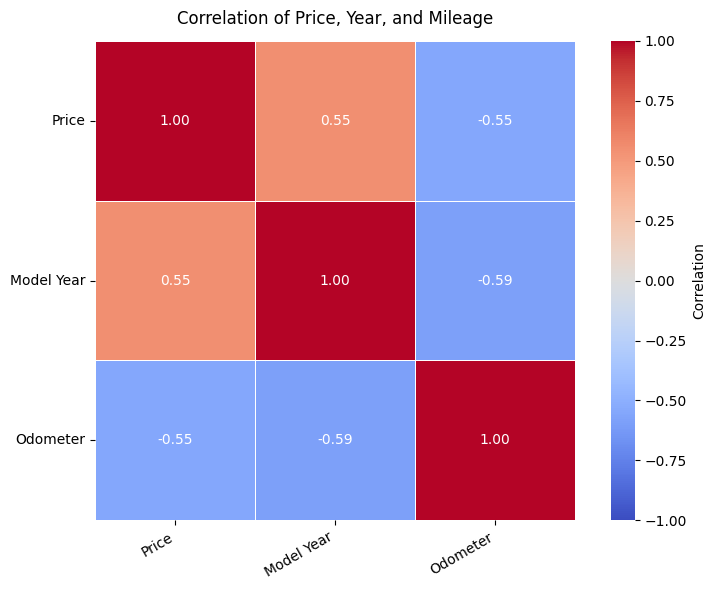

In [9]:
# Filter obvious listing errors before checking numeric correlations.
# This keeps the heatmap focused on typical used-car listings.
corr_data = data[
    data["price"].between(500, 100000)
    & data["year"].between(1980, 2022)
    & data["odometer"].between(100, 300000)
][["price", "year", "odometer"]].rename(
    columns={
        "price": "Price",
        "year": "Model Year",
        "odometer": "Odometer",
    }
)

correlations = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation of Price, Year, and Mileage", pad=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** My numeric review shows important quality issues: some listings have zero prices, extremely high prices, missing year/odometer values, and many missing categorical fields. These issues are why the modeling dataset is cleaned before fitting regression models.

The correlation heatmap gives a quick view of numeric relationships, while the filtered histograms and scatterplot make the price, model year, and mileage patterns easier to read. Because most vehicle details are categorical, Median-price summaries are also used later to support the coefficient interpretation.

In [10]:
# Check missing-value rates to decide which columns need cleaning or imputation.
missing_summary = (
    data.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_summary.columns = ["column", "missing_percent"]
missing_summary.head(15)

,column,missing_percent
0,size,71.767476
1,cylinders,41.622470
2,condition,40.785232
3,VIN,37.725356
4,drive,30.586347
5,paint_color,30.501078
6,type,21.752717
7,manufacturer,4.133714
8,title_status,1.930753
9,model,1.236179


**Missing-value interpretation:** Several useful categorical fields have high missing rates, especially `size`, `cylinders`, `condition`, `drive`, and `paint_color`.

For the starter model, I keep these columns and impute missing values as `unknown` so missingness is handled consistently without dropping too many rows.

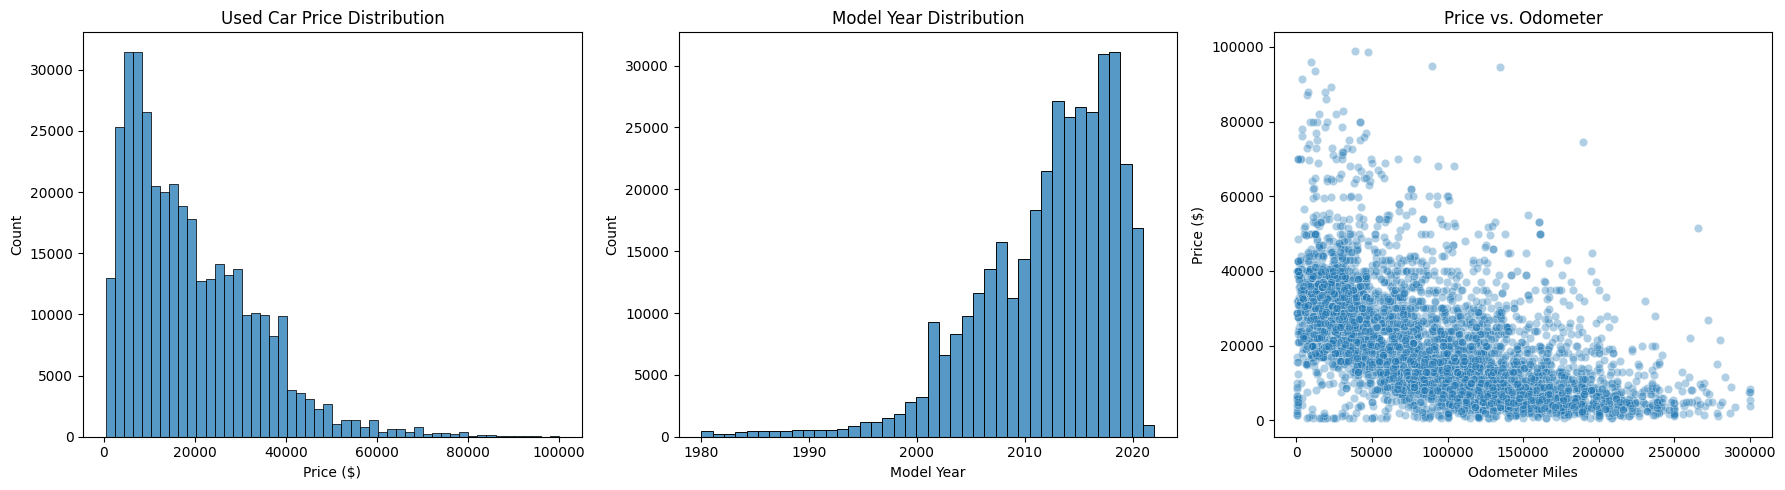

In [11]:
# Filter only for this visualization so outliers do not hide the main patterns.
eda_data = data[
    data["price"].between(500, 100000)
    & data["year"].between(1980, 2022)
    & data["odometer"].between(100, 300000)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(eda_data["price"], bins=50, ax=axes[0])
axes[0].set_title("Used Car Price Distribution")
axes[0].set_xlabel("Price ($)")

sns.histplot(eda_data["year"], bins=40, ax=axes[1])
axes[1].set_title("Model Year Distribution")
axes[1].set_xlabel("Model Year")

sns.scatterplot(
    data=eda_data.sample(min(5000, len(eda_data)), random_state=RANDOM_STATE),
    x="odometer",
    y="price",
    alpha=0.35,
    ax=axes[2],
)
axes[2].set_title("Price vs. Odometer")
axes[2].set_xlabel("Odometer Miles")
axes[2].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

**Visual interpretation:** Most used-car prices are concentrated below about $40,000, and the dataset contains many newer vehicles from the 2010s and early 2020s.

The odometer scatterplot shows a clear downward pattern, suggesting that higher mileage is generally associated with lower price.

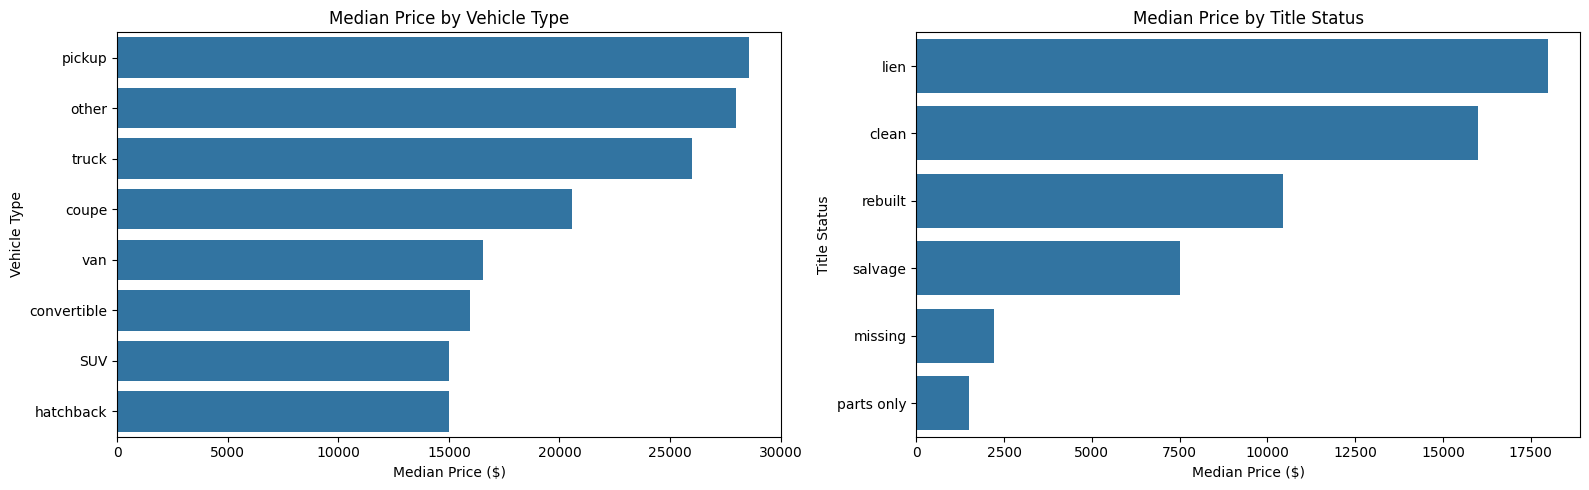

In [12]:
# Compare median prices across categorical features that are useful for dealers.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_order = (
    eda_data.groupby("type")["price"]
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index
)
sns.barplot(
    data=eda_data[eda_data["type"].isin(type_order)],
    x="price",
    y="type",
    estimator=np.median,
    order=type_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Median Price by Vehicle Type")
axes[0].set_xlabel("Median Price ($)")
axes[0].set_ylabel("Vehicle Type")

title_order = (
    eda_data.groupby("title_status")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.barplot(
    data=eda_data,
    x="price",
    y="title_status",
    estimator=np.median,
    order=title_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Median Price by Title Status")
axes[1].set_xlabel("Median Price ($)")
axes[1].set_ylabel("Title Status")

plt.tight_layout()
plt.show()

**Categorical visual interpretation:** The vehicle type chart supports the finding that pickups and trucks have stronger median prices than many passenger-car body types. The title status chart supports the recommendation to be cautious with salvage, missing-title, or parts-only vehicles because their median prices are much lower.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Data preparation approach**

I keep the original data unchanged and create a cleaned modeling table for the regression work. The preparation removes identifiers, filters implausible prices and mileage, creates `vehicle_age`, cleans the raw `model` field, groups rare categories, and prepares the selected predictors with a pipeline.

A **pipeline** keeps filling missing values, scaling numeric fields, and one-hot encoding categorical fields inside the model workflow. This matters because cross-validation should fit each preparation step on the training fold only, not on data that is being used for validation.

The feature set starts with information a dealer would normally know when pricing a used car. I also create `model_clean` from the raw `model` field, group rare model names, and test whether adding it improves cross-validated MAE before using it in the final model.

In [13]:
# Import the regression, preprocessing, and model-selection tools used below.
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [14]:
# Work from a copy so the raw data and earlier EDA stay intact.
clean_data = data.copy()

# Remove identifiers and duplicate location text, but keep model for a cleaned feature test.
clean_data = clean_data.drop(columns=["id", "VIN", "region"], errors="ignore")

# Remove likely listing errors found during data understanding.
clean_data = clean_data[clean_data["price"].between(500, 100000)]
clean_data = clean_data[clean_data["year"].between(1980, 2022)]
clean_data = clean_data[clean_data["odometer"].between(100, 300000)]

# Keep rows with the core fields needed for price modeling.
required_columns = ["manufacturer", "fuel", "transmission", "title_status", "year", "odometer", "price"]
clean_data = clean_data.dropna(subset=required_columns)

# Clean model names with basic text standardization before rare-category grouping.
clean_data["model_clean"] = (
    clean_data["model"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Use the newest model year in the cleaned data as the reference year for vehicle age.
reference_year = int(clean_data["year"].max())
clean_data["vehicle_age"] = reference_year - clean_data["year"]

# Use log1p, or log(1 + x), to reduce skew in price and mileage while safely handling zeros.
clean_data["odometer_log"] = np.log1p(clean_data["odometer"])
clean_data["price_log"] = np.log1p(clean_data["price"])

print(f"Reference year used for vehicle age: {reference_year}")
clean_data.shape

Reference year used for vehicle age: 2022


(346436, 19)

In [15]:
# Age and mileage are kept as core numeric pricing signals.
numeric_features = ["vehicle_age", "odometer", "odometer_log"]

# Start with vehicle descriptors already supported by the EDA.
base_categorical_features = [
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "size",
    "type",
    "paint_color",
    "state",
]

# Add cleaned model names as a candidate feature, then test whether they help.
model_categorical_feature = ["model_clean"]
candidate_categorical_features = base_categorical_features + model_categorical_feature
candidate_model_features = numeric_features + candidate_categorical_features

# Keep only the selected candidate features and target columns used for modeling.
model_data = clean_data[candidate_model_features + ["price", "price_log"]].copy()

# Sample for runtime while keeping enough rows for stable patterns.
max_model_rows = 50000
if len(model_data) > max_model_rows:
    model_data = model_data.sample(max_model_rows, random_state=RANDOM_STATE)

# Group rare categories to avoid unstable one-hot encoded columns.
min_category_count = 100
for column in candidate_categorical_features:
    model_data[column] = model_data[column].fillna("unknown")
    category_counts = model_data[column].value_counts()
    common_categories = category_counts[category_counts >= min_category_count].index
    model_data[column] = np.where(
        model_data[column].isin(common_categories),
        model_data[column],
        "other_low_count",
    )

X = model_data[candidate_model_features]
y = model_data["price_log"]

# Hold out 20% for final evaluation after model selection.
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training rows: {X_train_all.shape[0]:,}")
print(f"Test rows: {X_test_all.shape[0]:,}")

Training rows: 40,000
Test rows: 10,000


In [16]:
# Keep preparation steps inside the pipeline to reduce leakage.
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=True)


def build_preprocessor(categorical_columns):
    numeric_transformer = Pipeline(
        steps=[
            ("fill_missing", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("fill_missing", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("onehot", one_hot),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_columns),
        ]
    )

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

**Modeling approach**

The modeling stays intentionally simple and uses methods covered in the program. Linear Regression is the baseline, Ridge tests whether light regularization improves stability, and Lasso tests whether stronger coefficient shrinking helps when many one-hot encoded categories are present.

My optimization path is results-based. First, I test whether adding `model_clean` improves cross-validated MAE. Then I compare the three regression models on the selected feature set, tune `alpha` for Ridge and Lasso, and save the held-out test set for the final performance check.

In [17]:
# Use cross-validation to test feature choices before the test set is used.
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

feature_sets = {
    "Base features": base_categorical_features,
    "Base features + cleaned model": candidate_categorical_features,
}

feature_set_results = []
for feature_set_name, cat_columns in feature_sets.items():
    feature_columns = numeric_features + cat_columns
    feature_pipeline = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(cat_columns)),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    scores = cross_val_score(
        feature_pipeline,
        X_train_all[feature_columns],
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )
    feature_set_results.append(
        {
            "feature_set": feature_set_name,
            "feature_count": len(feature_columns),
            "mean_cv_mae_log_price": -scores.mean(),
            "std_cv_mae_log_price": scores.std(),
        }
    )

feature_set_results_df = pd.DataFrame(feature_set_results).sort_values("mean_cv_mae_log_price")
display(feature_set_results_df)

# Use the feature set with the lowest CV MAE for the model comparison.
selected_feature_set = feature_set_results_df.iloc[0]["feature_set"]
if selected_feature_set == "Base features + cleaned model":
    categorical_features = candidate_categorical_features
else:
    categorical_features = base_categorical_features

model_features = numeric_features + categorical_features
preprocessor = build_preprocessor(categorical_features)
X_train = X_train_all[model_features].copy()
X_test = X_test_all[model_features].copy()

print("Selected feature set:", selected_feature_set)
print("Number of model features before one-hot encoding:", len(model_features))

# Compare the baseline and regularized models with the selected feature set.
models = {
    "Linear Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", LinearRegression())]
    ),
    "Ridge Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", Ridge())]
    ),
    "Lasso Regression": Pipeline(
        steps=[("preprocess", preprocessor), ("model", Lasso(max_iter=10000))]
    ),
}

cv_results = []
for model_name, model_pipeline in models.items():
    scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
    )
    cv_results.append(
        {
            "model": model_name,
            "mean_cv_mae_log_price": -scores.mean(),
            "std_cv_mae_log_price": scores.std(),
        }
    )

# Sort by mean CV MAE; the lowest error drives the next tuning decision.
cv_results_df = pd.DataFrame(cv_results).sort_values("mean_cv_mae_log_price")
cv_results_df

,feature_set,feature_count,mean_cv_mae_log_price,std_cv_mae_log_price
1,Base features + cleaned model,15,0.301298,0.000157
0,Base features,14,0.312472,0.000172


Selected feature set: Base features + cleaned model
Number of model features before one-hot encoding: 15


,model,mean_cv_mae_log_price,std_cv_mae_log_price
1,Ridge Regression,0.301298,0.000157
0,Linear Regression,0.301346,0.000115
2,Lasso Regression,0.716827,0.002507


**Interpretation:** The feature check tests `model_clean` instead of assuming it helps. Adding cleaned model names improves cross-validated MAE on log price from about 0.312 to about 0.301, so I keep `model_clean` in the final feature set.

After selecting the feature set, cross-validation compares Linear Regression, Ridge Regression, and Lasso Regression. Ridge and Linear Regression are nearly tied, while Lasso performs much worse with its default setting, so Ridge becomes the main model to tune.

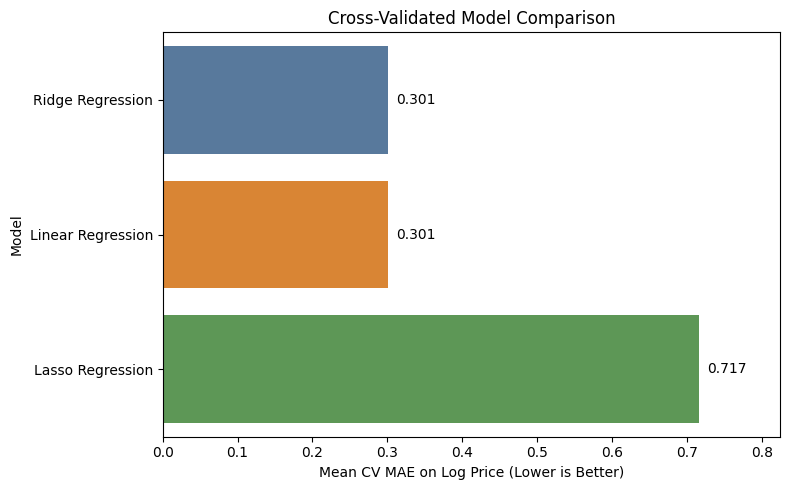

In [18]:
# Visualize model selection; lower cross-validated MAE is better.
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cv_results_df,
    x="mean_cv_mae_log_price",
    y="model",
    hue="model",
    palette=["#4C78A8", "#F58518", "#54A24B"],
    legend=False,
)
plt.title("Cross-Validated Model Comparison")
plt.xlabel("Mean CV MAE on Log Price (Lower is Better)")
plt.ylabel("Model")
plt.xlim(0, cv_results_df["mean_cv_mae_log_price"].max() * 1.15)
for index, row in cv_results_df.reset_index(drop=True).iterrows():
    plt.text(
        row["mean_cv_mae_log_price"] + 0.01,
        index,
        f'{row["mean_cv_mae_log_price"]:.3f}',
        va="center",
    )
plt.tight_layout()
plt.show()

**Model selection visual:** This chart compares cross-validated MAE for the three starter models after adding `model_clean`. Lower is better, and Ridge has the smallest average error by a very small margin over Linear Regression.

This is the second model-selection checkpoint. It shows that light regularization is enough for this version, so the next step tunes `alpha` instead of adding more complex models.

In [19]:
# Tune alpha only, using a slightly wider grid to show how regularization changes CV error.
ridge_search = GridSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=cv,
    scoring="neg_mean_absolute_error",
)

lasso_search = GridSearchCV(
    Pipeline(steps=[("preprocess", preprocessor), ("model", Lasso(max_iter=20000))]),
    param_grid={"model__alpha": [0.00005, 0.0001, 0.00025, 0.0005, 0.001, 0.005, 0.01]},
    cv=cv,
    scoring="neg_mean_absolute_error",
)

# Fit both searches on training folds only; the test set is still untouched.
ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)

# Capture the best alpha and CV MAE so the optimization decision is visible.
grid_results = pd.DataFrame(
    [
        {
            "model": "Ridge Regression",
            "best_alpha": ridge_search.best_params_["model__alpha"],
            "best_cv_mae_log_price": -ridge_search.best_score_,
        },
        {
            "model": "Lasso Regression",
            "best_alpha": lasso_search.best_params_["model__alpha"],
            "best_cv_mae_log_price": -lasso_search.best_score_,
        },
    ]
)

grid_results.sort_values("best_cv_mae_log_price")

,model,best_alpha,best_cv_mae_log_price
1,Lasso Regression,0.00005,0.301235
0,Ridge Regression,1.00000,0.301298


**Interpretation:** A **hyperparameter** is a model setting chosen before the final fit. Here, alpha controls regularization strength, and grid search compares several alpha values using cross-validation.

The expanded grid changes the model-selection result slightly: Lasso performs best at the smallest alpha tested, with cross-validated MAE about 0.3012 on log price. Ridge is almost tied, so the practical takeaway is that very light regularization works best and stronger Lasso regularization removes too much useful pricing signal.

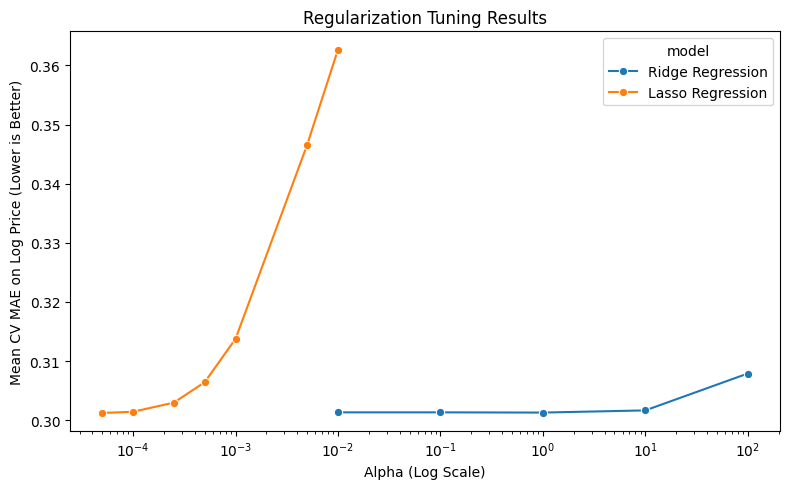

In [20]:
# Visualize whether tuning the regularization strength improves performance.
ridge_tuning = pd.DataFrame(ridge_search.cv_results_)
ridge_tuning["model"] = "Ridge Regression"
ridge_tuning["alpha"] = ridge_tuning["param_model__alpha"].astype(float)
ridge_tuning["mean_cv_mae_log_price"] = -ridge_tuning["mean_test_score"]

lasso_tuning = pd.DataFrame(lasso_search.cv_results_)
lasso_tuning["model"] = "Lasso Regression"
lasso_tuning["alpha"] = lasso_tuning["param_model__alpha"].astype(float)
lasso_tuning["mean_cv_mae_log_price"] = -lasso_tuning["mean_test_score"]

tuning_results = pd.concat([ridge_tuning, lasso_tuning], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=tuning_results,
    x="alpha",
    y="mean_cv_mae_log_price",
    hue="model",
    marker="o",
)
plt.xscale("log")
plt.title("Regularization Tuning Results")
plt.xlabel("Alpha (Log Scale)")
plt.ylabel("Mean CV MAE on Log Price (Lower is Better)")
plt.tight_layout()
plt.show()

**Improvement visual:** The tuning plot shows how cross-validated error changes as alpha changes. Ridge stays stable with low error across the tested values, while Lasso is most competitive only at very small alpha values.

This supports the final decision to use the tuned Lasso model in this run, while noting that the improvement over Ridge is very small. If this model is refined later, the search should focus on very small Lasso alpha values and confirm the result with more folds or a larger sample.

In [21]:
# GridSearchCV scores are negative MAE, so the higher best_score_ means lower error.
best_search = ridge_search if ridge_search.best_score_ >= lasso_search.best_score_ else lasso_search
best_model_name = "Ridge Regression" if best_search is ridge_search else "Lasso Regression"
best_model = best_search.best_estimator_

best_model_name

'Lasso Regression'

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Evaluation approach**

After model selection, the chosen Ridge model is fit on the training data and evaluated on the held-out test set. Because the target was modeled as log price, predictions are converted back to dollars before MAE and RMSE are reported.

The evaluation checks whether the optimization decision holds up outside cross-validation. Test MAE and RMSE show pricing error in dollars, the actual-vs-predicted plot shows where errors are larger, and coefficients explain which vehicle characteristics are most associated with higher or lower prices.

In [22]:
# Refit the selected model on the full training set before final evaluation.
best_model.fit(X_train, y_train)
y_pred_log = best_model.predict(X_test)

# Convert log-price predictions back to dollars for MAE and RMSE.
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_log)

# Report test metrics only after model selection is complete.
evaluation_metrics = pd.DataFrame(
    [
        {
            "best_model": best_model_name,
            "test_mae_dollars": mean_absolute_error(y_test_dollars, y_pred_dollars),
            "test_rmse_dollars": np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars)),
            "test_r2_log_price": r2_score(y_test, y_pred_log),
        }
    ]
)

evaluation_metrics

,best_model,test_mae_dollars,test_rmse_dollars,test_r2_log_price
0,Lasso Regression,4738.64069,7597.705306,0.698249


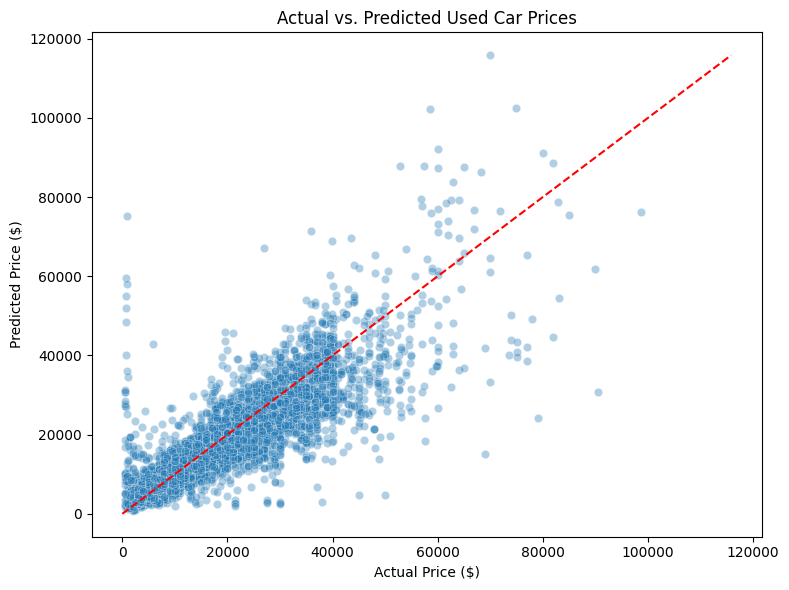

In [23]:
# Add the diagonal line to show perfect prediction; points near it are better predictions.
prediction_check = pd.DataFrame(
    {"actual_price": y_test_dollars, "predicted_price": y_pred_dollars}
).sample(min(5000, len(y_test_dollars)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=prediction_check, x="actual_price", y="predicted_price", alpha=0.35)
max_price = prediction_check[["actual_price", "predicted_price"]].max().max()
plt.plot([0, max_price], [0, max_price], color="red", linestyle="--")
plt.title("Actual vs. Predicted Used Car Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.tight_layout()
plt.show()

**Visual interpretation:** The points generally follow the diagonal line, so the model captures the overall relationship between actual and predicted prices. The wider spread at higher prices shows the model is less reliable for expensive vehicles.

In [24]:
# Extract coefficients so the model can be interpreted for the dealership.
cat_encoder = (
    best_model.named_steps["preprocess"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

try:
    categorical_names = cat_encoder.get_feature_names_out(categorical_features)
except AttributeError:
    categorical_names = cat_encoder.get_feature_names(categorical_features)

feature_names = numeric_features + list(categorical_names)
coefficients = best_model.named_steps["model"].coef_

coef_table = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient_log_price": coefficients,
    }
)
coef_table["absolute_value"] = coef_table["coefficient_log_price"].abs()

# Show the strongest positive and negative associations with predicted price.
top_positive = coef_table.sort_values("coefficient_log_price", ascending=False).head(15)
top_negative = coef_table.sort_values("coefficient_log_price").head(15)

display(top_positive)
display(top_negative)

,feature,coefficient_log_price,absolute_value
155,model_clean_corvette,0.661432,0.661432
29,manufacturer_porsche,0.593049,0.593049
34,manufacturer_tesla,0.442479,0.442479
208,model_clean_wrangler unlimited,0.376681,0.376681
207,model_clean_wrangler,0.328772,0.328772
195,model_clean_silverado,0.288478,0.288478
197,model_clean_silverado 2500hd,0.286367,0.286367
143,model_clean_4runner,0.262053,0.262053
166,model_clean_f-250,0.242281,0.242281
201,model_clean_tacoma,0.237737,0.237737


,feature,coefficient_log_price,absolute_value
42,condition_other_low_count,-0.855420,0.855420
51,fuel_electric,-0.743179,0.743179
38,condition_fair,-0.701889,0.701889
53,fuel_hybrid,-0.676551,0.676551
52,fuel_gas,-0.644841,0.644841
32,manufacturer_saturn,-0.549180,0.549180
54,fuel_other,-0.537286,0.537286
44,cylinders_4 cylinders,-0.536990,0.536990
45,cylinders_5 cylinders,-0.507792,0.507792
23,manufacturer_mercury,-0.486441,0.486441


In [25]:
# Use median-price summaries to explain coefficient patterns in plain language.
for column in ["condition", "fuel", "transmission", "drive", "type", "title_status"]:
    display(
        clean_data.groupby(column)["price"]
        .agg(["count", "median"])
        .sort_values("median", ascending=False)
        .head(10)
    )

,count,median
condition,,
good,110377,21590.0
new,644,17000.0
like new,18253,14900.0
excellent,80765,11975.0
fair,5241,2600.0
salvage,443,2000.0


,count,median
fuel,,
diesel,21243,33990.0
other,26047,27990.0
electric,1449,25995.0
gas,293127,13995.0
hybrid,4570,13000.0


,count,median
transmission,,
other,57634,28990.0
automatic,271368,13000.0
manual,17434,9990.0


,count,median
drive,,
4wd,109440,21500.0
rwd,45241,19590.0
fwd,89554,10750.0


,count,median
type,,
pickup,38595,28590.0
other,17862,28590.0
truck,26434,26000.0
coupe,14827,21888.0
van,6776,16496.5
convertible,6029,16000.0
SUV,63418,14999.0
hatchback,14079,14990.0
bus,254,14900.0


,count,median
title_status,,
lien,1312,18000.0
clean,334561,16000.0
rebuilt,6676,10416.5
salvage,3529,7500.0
missing,270,2200.0
parts only,88,1500.0


**Evaluation interpretation**

After expanding the alpha grid, tuned Lasso is selected because it has the lowest cross-validated MAE, though Ridge is nearly tied. On the held-out test set, Lasso has MAE about 4,739 dollars, RMSE about 7,598 dollars, and log-price R-squared about 0.698.

The actual-vs-predicted plot shows that the model follows the overall price pattern, but errors spread out more for higher-priced vehicles. Coefficients provide direction and relative importance, while the earlier median-price charts help translate those coefficient patterns into dealership language.

**Descriptive and inferential statistics interpretation**

For descriptive statistics, I use missing-value rates, filtered distributions, correlations, and median-price summaries by category. Addtional, I use cross-validation and the held-out test set, which estimate how well the regression models are likely to perform on listings not used to fit the model.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**Deployment summary for the dealership**

I would use the Ridge model as a pricing support tool, not an automatic pricing rule. The model highlights the listing signals dealers should review most closely: vehicle age, mileage, cleaned model name, title status, body type, drivetrain, fuel type, manufacturer, and condition.

**Primary findings**

- Adding `model_clean` improved cross-validated MAE, so cleaned model names are useful pricing signals.
- Newer, lower-mileage vehicles with clean titles generally support stronger prices.
- Pickups, trucks, premium manufacturers, and specific models such as Corvette, Wrangler, Silverado, 4Runner, and F-Series trucks show stronger positive price associations.

**Recommendations for dealers**

- Prioritize clean-title, lower-mileage inventory with stronger body/model combinations.
- Price older, high-mileage, salvage, parts-only, or missing-title vehicles more conservatively.
- Improve listing completeness for condition, drive, size, type, model, and paint color before relying on model-supported pricing.

**Next steps**

1. Refine `model_clean` for trims, abbreviations, and overlapping model names.
2. Review large-error records, especially luxury, electric, and specialty vehicles.
3. Expand the Ridge/Lasso alpha grid only after confirming the feature improvements are stable.

In [26]:
# Display the final summary tables used in the report section.
print("Best model:", best_model_name)
display(evaluation_metrics)
display(top_positive.head(10))
display(top_negative.head(10))

Best model: Lasso Regression


,best_model,test_mae_dollars,test_rmse_dollars,test_r2_log_price
0,Lasso Regression,4738.64069,7597.705306,0.698249


,feature,coefficient_log_price,absolute_value
155,model_clean_corvette,0.661432,0.661432
29,manufacturer_porsche,0.593049,0.593049
34,manufacturer_tesla,0.442479,0.442479
208,model_clean_wrangler unlimited,0.376681,0.376681
207,model_clean_wrangler,0.328772,0.328772
195,model_clean_silverado,0.288478,0.288478
197,model_clean_silverado 2500hd,0.286367,0.286367
143,model_clean_4runner,0.262053,0.262053
166,model_clean_f-250,0.242281,0.242281
201,model_clean_tacoma,0.237737,0.237737


,feature,coefficient_log_price,absolute_value
42,condition_other_low_count,-0.855420,0.855420
51,fuel_electric,-0.743179,0.743179
38,condition_fair,-0.701889,0.701889
53,fuel_hybrid,-0.676551,0.676551
52,fuel_gas,-0.644841,0.644841
32,manufacturer_saturn,-0.549180,0.549180
54,fuel_other,-0.537286,0.537286
44,cylinders_4 cylinders,-0.536990,0.536990
45,cylinders_5 cylinders,-0.507792,0.507792
23,manufacturer_mercury,-0.486441,0.486441


**My interpretation:** 
Lasso Regression is the final model for this run because the expanded alpha grid found a very small alpha that slightly improves cross-validated MAE. The held-out test results show an average pricing error of about 4,739 dollars and log-price R-squared of about 0.698, so the model is useful for guidance but not precise enough to set prices automatically.

The strongest positive coefficients point to cleaned model names and premium manufacturers, including Corvette, Porsche, Tesla, Wrangler, Silverado, 4Runner, F-250, and F-350. This supports a practical dealership story: cleaned model information adds useful pricing signal, while listing completeness, title status, mileage, and vehicle type still matter for pricing confidence.